# Supplementary S5.3 — control analyses

Two checks, each producing one table and one paragraph of results.

**S5.3.2 — recreation accuracy across trials.** Did participants get better or worse at recreating
the validation images over the course of the experiment? Error is the absolute difference between
a recreation's feature value and that of the image shown. Trial number enters as a categorical
predictor, so no shape of change is assumed, with a participant random intercept: the mixed-model
equivalent of a repeated-measures ANOVA. One omnibus test per feature, Holm-corrected (m = 5).

**S5.3.3 — trial order and session.** The main validation and experimental models are refitted with
a linear term for trial position and nested random intercepts for participant within session. Here
trial position must be linear rather than categorical: within a session the order was fixed, so
condition and position are perfectly confounded and only a 1-df summary is identifiable. Two
families of ten tests (5 features x 2 nuisance terms), Holm-corrected within each.

Run top to bottom; about a minute. Optional checks are at the end and are not needed for the
supplement.

In [2]:
## setup

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.stats import chi2

warnings.filterwarnings("ignore")

project_path = Path().resolve().parent
tables_path = os.path.join(project_path, "015_tables")

FEATURES = {
    "detail": "detail level",
    "r_directionality": "radial orientation",
    "theta_directionality": "tangential orientation",
    "brightness": "brightness",
    "contrast": "contrast",
}

FILE_TYPE_KEEP = "cropped"     # "uncropped" rows are duplicate renders of the same drawing
DROP_TRIALN = [1]              # make-up trials for late arrivals; outside the ordered sequence
OPTIMISERS = ("bfgs", "powell", "cg", "nm")           # lbfgs is unreliable on these models
VC_NESTED = {"participant": "0 + C(participant_code)"}  # participant within session

FNAME_PATTERN = (
    r"sessionTime_(?P<session>\d+)"
    r".*?participant_(?P<pid_file>[A-Za-z0-9]+)"
    r".*?trialN_(?P<trialn_file>\d+)"
    r".*?trialT_(?P<trialt_file>[A-Za-z0-9]+)"
    r"__fileType_(?P<file_type>[A-Za-z0-9]+)\.png"
)

In [3]:
## load and prepare

df_vizex = pd.read_csv(os.path.join(tables_path, "vizex_features.csv"))
df_targets = pd.read_csv(os.path.join(tables_path, "vizex_targets_features.csv"))

meta = df_vizex["png_filename"].astype(str).str.extract(FNAME_PATTERN)
assert meta["session"].notna().all(), "Filename pattern failed."
d = pd.concat([df_vizex, meta], axis=1)

d = d[d["file_type"] == FILE_TYPE_KEEP]
d = d[~d["trialn"].astype(int).isin(DROP_TRIALN)].copy()
d["session"] = d["session"].astype(str)
d["condition_code"] = d["condition_code"].astype(str)
d["trial_pos"] = d["trialn"].astype(int) - int(d["trialn"].astype(int).min()) + 1

TRIAL_SPAN = int(d["trial_pos"].max() - d["trial_pos"].min())
d["trial_c"] = d["trial_pos"] - d["trial_pos"].mean()

# --- experimental subset: SLS trials ---
exp = d[d["stimulus_type"] == "LIGHT"].copy()
exp["condition_hz"] = pd.to_numeric(exp["condition_hz"], errors="coerce").round(2)
for f in FEATURES:
    exp[f] = pd.to_numeric(exp[f], errors="coerce")
exp = exp.dropna(subset=list(FEATURES) + ["condition_hz", "session", "participant_code"]).copy()
for f in FEATURES:
    exp["z_" + f] = (exp[f] - exp[f].mean()) / exp[f].std(ddof=1)

# --- validation subset: static image trials, joined to their target images ---
tg = df_targets.copy()
tg["condition_code"] = tg["condition_code"].astype(str)
tg = tg[["condition_code"] + list(FEATURES)].rename(columns={f: "stim_" + f for f in FEATURES})

val = d[(d["stimulus_type"] != "LIGHT") & (d["condition_code"].isin(set(tg["condition_code"])))].copy()
val = val.merge(tg, on="condition_code", how="left", validate="many_to_one")
for f in FEATURES:
    val[f] = pd.to_numeric(val[f], errors="coerce")
    val["stim_" + f] = pd.to_numeric(val["stim_" + f], errors="coerce")
val = val.dropna(subset=list(FEATURES) + ["stim_" + f for f in FEATURES]).copy()

for f in FEATURES:
    m, s = val[f].mean(), val[f].std(ddof=1)
    val["z_" + f] = (val[f] - m) / s                     # recreation, z-scored
    val["zs_" + f] = ((val["stim_" + f] - val["stim_" + f].mean())
                      / val["stim_" + f].std(ddof=1))     # stimulus, standardised covariate
    val["err_" + f] = ((val[f] - val["stim_" + f]) / s).abs()   # absolute error, in recreation SDs

print(f"experimental : {len(exp):>5} drawings, {exp['participant_code'].nunique()} participants")
print(f"validation   : {len(val):>5} drawings, {val['participant_code'].nunique()} participants, "
      f"{val['condition_code'].nunique()} target images")
print(f"sessions     : {d['session'].nunique():>5}   trial positions 1-{d['trial_pos'].max()}")

experimental :  1282 drawings, 99 participants
validation   :   295 drawings, 99 participants, 45 target images
sessions     :    17   trial positions 1-16


In [4]:
## design checks

assert (d["pid_file"] == d["participant_code"]).all(), "filename participant mismatch"
assert (d["trialn_file"].astype(int) == d["trialn"].astype(int)).all(), "filename trial mismatch"
assert d.duplicated(["participant_code", "trialn"]).sum() == 0, "duplicate participant x trial rows"
assert (d.groupby("participant_code")["session"].nunique() == 1).all(), "participant spans sessions"

orders = (d.sort_values("trial_pos").groupby(["session", "participant_code"])["condition_type"]
            .apply(tuple).groupby("session"))
r2_collinear = smf.ols("trial_c ~ C(condition_hz)", exp).fit().rsquared
imgs_per_pos = val.groupby("trial_pos")["condition_code"].nunique()

print(f"sessions with one internal order   : {(orders.nunique() == 1).sum()} / {d['session'].nunique()}")
print(f"distinct orders across sessions    : {orders.first().nunique()} / {d['session'].nunique()}")
print(f"R^2 of trial position on frequency : {r2_collinear:.4f}   (VIF {1 / (1 - r2_collinear):.2f})")
print(f"target images per trial position   : {imgs_per_pos.min()}-{imgs_per_pos.max()}")
print("\nAll assertions passed. Orders differ between sessions and several target images appear at")
print("each position, so trial position is not tied to condition or to stimulus difficulty.")

sessions with one internal order   : 13 / 17
distinct orders across sessions    : 17 / 17
R^2 of trial position on frequency : 0.0143   (VIF 1.01)
target images per trial position   : 6-30

All assertions passed. Orders differ between sessions and several target images appear at
each position, so trial position is not tied to condition or to stimulus difficulty.


In [5]:
## fitting helpers

def fit_best(formula, data, groups, vc_formula=None):
    # nested variance-component models can settle in poor local optima, which would corrupt the
    # likelihood-ratio tests; take the highest log-likelihood across optimisers
    model = smf.mixedlm(formula, data, groups=data[groups], re_formula="1", vc_formula=vc_formula)
    best, err = None, None
    for method in OPTIMISERS:
        try:
            res = model.fit(reml=False, method=method)
            if np.isfinite(res.llf) and (best is None or res.llf > best.llf):
                best = res
        except Exception as e:
            err = e
    if best is None:
        raise RuntimeError(f"all optimisers failed for '{formula}': {err}")
    return model, best


def lrt(res_full, res_reduced, df, boundary=False):
    stat = max(2 * (res_full.llf - res_reduced.llf), 0.0)
    p = chi2.sf(stat, df)
    return stat, (0.5 * p if boundary and stat > 0 else (1.0 if boundary else p))


def fixed_var(model, res, columns):
    names = list(model.exog_names)
    idx = [names.index(c) for c in columns if c in names]
    return float(np.var(np.asarray(model.exog)[:, idx] @ np.asarray(res.fe_params)[idx])) if idx else 0.0


def fmt_p(p):
    if not np.isfinite(p):
        return "-"
    return "< .001" if p < 0.001 else f"{p:.3f}".replace("0.", ".", 1)


def fmt_p_apa(p):
    return "p < .001" if p < 0.001 else "p = " + f"{p:.3f}".replace("0.", ".", 1)

## S5.3.2 — recreation accuracy across trials

`error ~ C(trial_number) + (1 | participant)`, tested by likelihood-ratio against the
intercept-only model. The effect size is the largest difference between any two trials' estimated
mean errors.

In [6]:
## fit

rows = []
for feat, name in FEATURES.items():
    y = "err_" + feat
    model, res = fit_best(f"{y} ~ C(trial_pos)", val, "participant_code")
    _, res0 = fit_best(f"{y} ~ 1", val, "participant_code")

    df_trial = len([c for c in model.exog_names if c.startswith("C(trial_pos)")])
    stat, p = lrt(res, res0, df_trial)

    means = np.asarray(model.exog) @ np.asarray(res.fe_params)
    spread = float(np.max(means) - np.min(means))

    rows.append({"Feature": name, "mean_err": val[y].mean(), "spread": spread,
                 "chi2": stat, "df": df_trial, "p": p})

acc = pd.DataFrame(rows)
acc["p_holm"] = multipletests(acc["p"], alpha=0.05, method="holm")[1]
print("fitted", len(acc), "models")

fitted 5 models


In [7]:
## table and results statement

ACC_DF = int(acc["df"].iloc[0])
table_acc = pd.DataFrame({
    "Feature": acc["Feature"],
    "Mean absolute error (SD)": acc["mean_err"].map("{:.3f}".format),
    "Largest difference between trials (SD)": acc["spread"].map("{:.3f}".format),
    f"chi2({ACC_DF})": acc["chi2"].map("{:.2f}".format),
    "p": [fmt_p(v) for v in acc["p_holm"]],
})
print(table_acc.to_string(index=False), "\n")

sig = acc[acc["p_holm"] < .05]
biggest = acc.loc[acc["spread"].idxmax()]
if sig.empty:
    print(f"Error did not differ reliably between trials for any feature (all Holm-corrected "
          f"p > .05). Mean absolute error was {acc['mean_err'].min():.2f}-{acc['mean_err'].max():.2f} SD "
          f"of the recreated feature, and the largest difference between any two trials was "
          f"{biggest['spread']:.2f} SD, for {biggest['Feature']} "
          f"(chi2({ACC_DF}) = {biggest['chi2']:.2f}, {fmt_p_apa(biggest['p_holm'])}).")
else:
    big_sig = sig.loc[sig["spread"].idxmax()]
    print(f"Error differed reliably between trials for {len(sig)} of 5 features "
          f"({', '.join(sig['Feature'])}); the largest such difference between any two trials was "
          f"{big_sig['spread']:.2f} SD, for {big_sig['Feature']} "
          f"(chi2({ACC_DF}) = {big_sig['chi2']:.2f}, {fmt_p_apa(big_sig['p_holm'])}). Mean absolute "
          f"error was {acc['mean_err'].min():.2f}-{acc['mean_err'].max():.2f} SD of the recreated feature.")

               Feature Mean absolute error (SD) Largest difference between trials (SD) chi2(14)      p
          detail level                    1.245                                  1.881    43.16 < .001
    radial orientation                    0.310                                  0.314    11.61  1.000
tangential orientation                    0.254                                  0.165     7.08  1.000
            brightness                    0.422                                  0.426    21.66   .343
              contrast                    0.445                                  0.367    10.96  1.000 

Error differed reliably between trials for 1 of 5 features (detail level); the largest such difference between any two trials was 1.88 SD, for detail level (chi2(14) = 43.16, p < .001). Mean absolute error was 0.25-1.25 SD of the recreated feature.


## S5.3.3 — trial order and experimental session

The main models refitted as
`feature ~ condition + trial_position + (1 | session) + (1 | participant within session)`.
Trial position is tested by likelihood-ratio against the model without it; session by
likelihood-ratio against a participant-only random intercept, with the boundary correction
appropriate to a variance parameter. The last block refits the main experimental model without
these terms to confirm the frequency coefficients do not depend on them.

In [8]:
## fit both families

def run_family(data, template, main_prefix, label):
    rows = []
    for feat, name in FEATURES.items():
        formula = template.format(f=feat)
        model, res = fit_best(formula, data, "session", VC_NESTED)
        _, res_notrial = fit_best(formula.replace(" + trial_c", ""), data, "session", VC_NESTED)
        _, res_nosession = fit_best(formula, data, "participant_code")

        main_cols = [c for c in model.exog_names if c.startswith(main_prefix)]
        v = {"main": fixed_var(model, res, main_cols),
             "trial": fixed_var(model, res, ["trial_c"]),
             "session": float(np.asarray(res.cov_re)[0, 0]),
             "participant": float(np.atleast_1d(res.vcomp)[0]),
             "resid": float(res.scale)}
        total = sum(v.values())

        chi_t, p_t = lrt(res, res_notrial, 1)
        chi_s, p_s = lrt(res, res_nosession, 1, boundary=True)
        b = float(res.fe_params["trial_c"])
        try:
            se = float(res.bse_fe["trial_c"])
        except Exception:
            se = np.nan

        rows.append({"Trials": label, "Feature": name, "b": b, "se": se,
                     "chi2_trial": chi_t, "p_trial": p_t, "drift": b * TRIAL_SPAN,
                     "chi2_session": chi_s, "p_session": p_s,
                     **{f"pct_{k}": 100 * val_ / total for k, val_ in v.items()}})
    out = pd.DataFrame(rows)
    p_all = multipletests(np.r_[out["p_trial"], out["p_session"]], alpha=0.05, method="holm")[1]
    out["p_trial_holm"] = p_all[:len(out)]
    out["p_session_holm"] = p_all[len(out):]
    return out


ord_exp = run_family(exp, "z_{f} ~ C(condition_hz) + trial_c", "C(condition_hz)", "Experimental")
ord_val = run_family(val, "z_{f} ~ zs_{f} + trial_c", "zs_", "Validation")
order_res = pd.concat([ord_exp, ord_val], ignore_index=True)

# does removing the nuisance terms move the frequency coefficients?
shifts, corrs = [], []
for feat in FEATURES:
    m_b, r_b = fit_best(f"z_{feat} ~ C(condition_hz)", exp, "participant_code")
    m_f, r_f = fit_best(f"z_{feat} ~ C(condition_hz) + trial_c", exp, "session", VC_NESTED)
    cols = [c for c in m_b.exog_names if c.startswith("C(condition_hz)")]
    shifts.append(np.max(np.abs(r_f.fe_params[cols].values - r_b.fe_params[cols].values)))
    corrs.append(np.corrcoef(r_b.fe_params[cols].values, r_f.fe_params[cols].values)[0, 1])
MAX_SHIFT, MIN_R = float(np.max(shifts)), float(np.min(corrs))
print("fitted", len(order_res), "models")

fitted 10 models


In [9]:
## table and results statement

table_order = pd.DataFrame({
    "Trials": order_res["Trials"],
    "Feature": order_res["Feature"],
    "b per trial (SE)": [f"{b:+.4f} (-)" if not np.isfinite(se) else f"{b:+.4f} ({se:.4f})"
                         for b, se in zip(order_res["b"], order_res["se"])],
    "chi2(1)": order_res["chi2_trial"].map("{:.2f}".format),
    "p": [fmt_p(v) for v in order_res["p_trial_holm"]],
    "Drift across experiment (SD)": order_res["drift"].map("{:+.3f}".format),
    "Trial order (% variance)": order_res["pct_trial"].map("{:.2f}".format),
    "Session chi2(1)": order_res["chi2_session"].map("{:.2f}".format),
    "Session p": [fmt_p(v) for v in order_res["p_session_holm"]],
    "Session (% variance)": order_res["pct_session"].map("{:.2f}".format),
})
print(table_order.to_string(index=False), "\n")


def describe(res_df, label):
    sig = res_df[res_df["p_trial_holm"] < .05]
    big = res_df.loc[res_df["drift"].abs().idxmax()]
    if sig.empty:
        return (f"in the {label} data no feature showed a reliable effect of trial position "
                f"(all Holm-corrected p > .05; largest drift {big['drift']:+.2f} SD across the "
                f"experiment, for {big['Feature']})")
    return (f"in the {label} data trial position had a statistically significant but very small "
            f"effect on {len(sig)} of the five features ({', '.join(sig['Feature'])}; largest, "
            f"{big['Feature']}: b = {big['b']:+.4f} SD per trial, {big['drift']:+.2f} SD across "
            f"the experiment)")


n_sess_sig = (order_res["p_session_holm"] < .05).sum()
print(f"Trial position and session were negligible: {describe(ord_exp, 'experimental')}, and "
      f"{describe(ord_val, 'validation')}. Adding a session-level random intercept "
      f"{'did not improve fit for any feature' if n_sess_sig == 0 else f'improved fit for {n_sess_sig} models'}. "
      f"Trial position accounted for under {order_res['pct_trial'].max():.1f}% and session for under "
      f"{order_res['pct_session'].max():.1f}% of total variance in every model. Including both terms "
      f"changed the frequency coefficients of the main experimental analysis by at most "
      f"{MAX_SHIFT:.3f} SD (r >= {MIN_R:.3f}).")

      Trials                Feature b per trial (SE) chi2(1)      p Drift across experiment (SD) Trial order (% variance) Session chi2(1) Session p Session (% variance)
Experimental           detail level -0.0192 (0.0046)   17.36 < .001                       -0.287                     0.78            0.08     1.000                 0.75
Experimental     radial orientation +0.0088 (0.0054)    2.68   .617                       +0.133                     0.17            0.00     1.000                 0.00
Experimental tangential orientation -0.0151 (0.0055)    7.67   .045                       -0.227                     0.49            0.00     1.000                 0.00
Experimental             brightness -0.0085 (0.0050)    2.91   .617                       -0.128                     0.15            0.03     1.000                 0.33
Experimental               contrast -0.0158 (0.0046)   11.56   .006                       -0.237                     0.53            1.16      .704        

## Export

Tab-separated output for pasting straight into Google Sheets, plus full-precision CSVs.

In [10]:
## tab-separated tables

def export(df, stem):
    path = os.path.join(tables_path, stem + ".tsv")
    df.to_csv(path, sep="\t", index=False)
    print("\t".join(map(str, df.columns)))
    for _, r in df.iterrows():
        print("\t".join(map(str, r.values)))
    print(f"[saved: {path}]\n")


print("TABLE S5.2  (Supplementary Section S5.3.2)")
export(table_acc, "table_S5.2_recreation_accuracy")
print("TABLE S5.3  (Supplementary Section S5.3.3)")
export(table_order, "table_S5.3_trial_order_session")

acc.to_csv(os.path.join(tables_path, "table_S5.2_raw.csv"), index=False)
order_res.to_csv(os.path.join(tables_path, "table_S5.3_raw.csv"), index=False)

TABLE S5.2  (Supplementary Section S5.3.2)
Feature	Mean absolute error (SD)	Largest difference between trials (SD)	chi2(14)	p
detail level	1.245	1.881	43.16	< .001
radial orientation	0.310	0.314	11.61	1.000
tangential orientation	0.254	0.165	7.08	1.000
brightness	0.422	0.426	21.66	.343
contrast	0.445	0.367	10.96	1.000
[saved: C:\Users\trevo\research\vizex_replication\015_tables\table_S5.2_recreation_accuracy.tsv]

TABLE S5.3  (Supplementary Section S5.3.3)
Trials	Feature	b per trial (SE)	chi2(1)	p	Drift across experiment (SD)	Trial order (% variance)	Session chi2(1)	Session p	Session (% variance)
Experimental	detail level	-0.0192 (0.0046)	17.36	< .001	-0.287	0.78	0.08	1.000	0.75
Experimental	radial orientation	+0.0088 (0.0054)	2.68	.617	+0.133	0.17	0.00	1.000	0.00
Experimental	tangential orientation	-0.0151 (0.0055)	7.67	.045	-0.227	0.49	0.00	1.000	0.00
Experimental	brightness	-0.0085 (0.0050)	2.91	.617	-0.128	0.15	0.03	1.000	0.33
Experimental	contrast	-0.0158 (0.0046)	11.56	.006	-0.23

---

## Optional checks

Not needed for the supplement. Run them if a reviewer asks; mention the answer in a clause only if
it changes a conclusion.

1. **Blocks rather than trials.** Participants broke after the 5th and 10th trials, so a
   three-level block factor is a lower-variance alternative to the 16-level test above.
2. **Full variance partition.** The percentages omitted from Table S5.3, for reference against
   Section 5.3.2.3.

In [11]:
## 1. accuracy by block rather than by trial

val["block"] = pd.cut(val["trial_pos"], bins=[0, 5, 10, 99], labels=["1-5", "6-10", "11+"])
rows = []
for feat, name in FEATURES.items():
    _, r1 = fit_best(f"err_{feat} ~ C(block)", val, "participant_code")
    _, r0 = fit_best(f"err_{feat} ~ 1", val, "participant_code")
    stat, p = lrt(r1, r0, 2)
    rows.append({"Feature": name, "chi2(2)": round(stat, 2), "p": p})
blocks = pd.DataFrame(rows)
blocks["p (Holm)"] = multipletests(blocks["p"], alpha=0.05, method="holm")[1]
display(blocks.round(4))

,Feature,chi2(2),p,p (Holm)
0,detail level,7.38,0.0250,0.1251
1,radial orientation,0.52,0.7715,1.0000
2,tangential orientation,0.63,0.7303,1.0000
3,brightness,3.05,0.2173,0.8692
4,contrast,2.96,0.2274,0.8692


In [12]:
## 2. full variance partition behind Table S5.3

display(order_res[["Trials", "Feature", "pct_main", "pct_trial", "pct_session",
                   "pct_participant", "pct_resid"]].round(2))

,Trials,Feature,pct_main,pct_trial,pct_session,pct_participant,pct_resid
0,Experimental,detail level,5.52,0.78,0.75,37.43,55.52
1,Experimental,radial orientation,7.73,0.17,0.00,14.61,77.49
2,Experimental,tangential orientation,7.36,0.49,0.00,12.85,79.31
3,Experimental,brightness,5.82,0.15,0.33,27.60,66.10
4,Experimental,contrast,5.46,0.53,2.62,34.24,57.14
5,Validation,detail level,51.85,0.16,3.10,8.79,36.09
6,Validation,radial orientation,89.93,0.01,0.00,0.00,10.06
7,Validation,tangential orientation,88.97,0.02,0.00,0.00,11.01
8,Validation,brightness,67.15,0.32,0.10,3.58,28.85
9,Validation,contrast,65.46,0.61,0.00,3.24,30.69


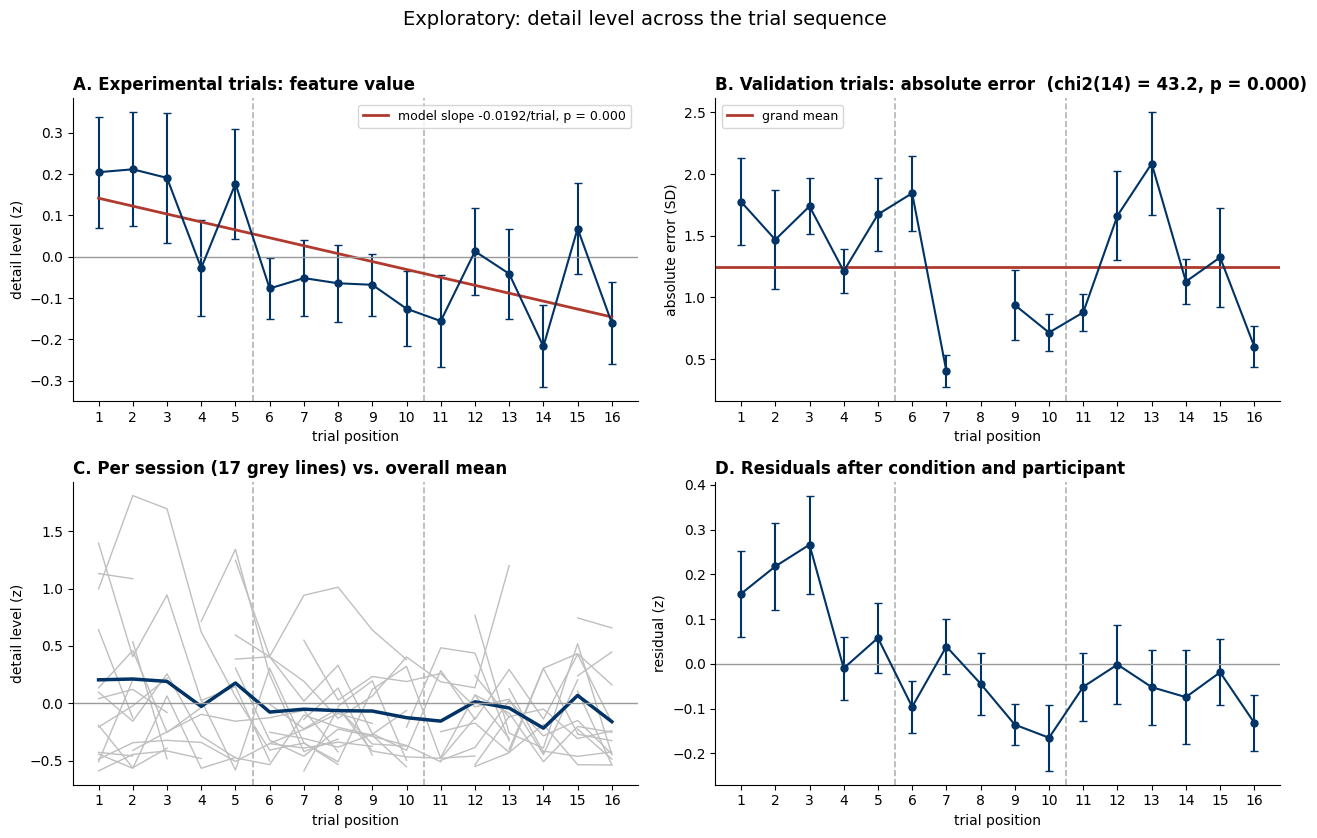

trials per position - experimental: 54-99, validation: 6-44


In [13]:
## exploratory: how does detail level behave across the trial sequence?

import matplotlib.pyplot as plt

FEAT = "detail"                      # change to inspect another feature
BREAKS = (5, 10)                     # breaks after the 5th and 10th trials
positions = np.arange(1, int(d["trial_pos"].max()) + 1)


def _mark_breaks(ax):
    for b in BREAKS:
        ax.axvline(b + 0.5, color="0.7", lw=1.2, ls="--", zorder=0)


def _by_pos(frame, col):
    g = frame.groupby("trial_pos")[col]
    return g.mean().reindex(positions), g.sem().reindex(positions)


fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
fig.suptitle(f"Exploratory: {FEATURES[FEAT]} across the trial sequence", fontsize=14, y=0.98)

# --- A. experimental feature values by trial position ---
ax = axes[0, 0]
m, se = _by_pos(exp, "z_" + FEAT)
_mark_breaks(ax)
ax.errorbar(positions, m, yerr=se, fmt="-o", color="#003366", ms=5, capsize=3)
row = ord_exp[ord_exp["Feature"] == FEATURES[FEAT]].iloc[0]
ax.plot(positions, row["b"] * (positions - exp["trial_pos"].mean()), color="#B03A2E", lw=2,
        label=f"model slope {row['b']:+.4f}/trial, p = {row['p_trial_holm']:.3f}")
ax.axhline(0, color="0.6", lw=1)
ax.set_title("A. Experimental trials: feature value", loc="left", fontweight="bold")
ax.set_xlabel("trial position"); ax.set_ylabel(f"{FEATURES[FEAT]} (z)"); ax.legend(fontsize=9)

# --- B. validation error by trial position ---
ax = axes[0, 1]
m, se = _by_pos(val, "err_" + FEAT)
_mark_breaks(ax)
ax.errorbar(positions, m, yerr=se, fmt="-o", color="#003366", ms=5, capsize=3)
ax.axhline(val["err_" + FEAT].mean(), color="#B03A2E", lw=2, label="grand mean")
arow = acc[acc["Feature"] == FEATURES[FEAT]].iloc[0]
ax.set_title(f"B. Validation trials: absolute error  (chi2({int(arow['df'])}) = {arow['chi2']:.1f}, "
             f"p = {arow['p_holm']:.3f})", loc="left", fontweight="bold")
ax.set_xlabel("trial position"); ax.set_ylabel("absolute error (SD)"); ax.legend(fontsize=9)

# --- C. is the trend driven by particular sessions? ---
ax = axes[1, 0]
_mark_breaks(ax)
for _, g in exp.groupby("session"):
    ax.plot(positions, g.groupby("trial_pos")["z_" + FEAT].mean().reindex(positions),
            color="0.75", lw=1)
m, _ = _by_pos(exp, "z_" + FEAT)
ax.plot(positions, m, color="#003366", lw=2.5)
ax.axhline(0, color="0.6", lw=1)
ax.set_title(f"C. Per session ({exp['session'].nunique()} grey lines) vs. overall mean",
             loc="left", fontweight="bold")
ax.set_xlabel("trial position"); ax.set_ylabel(f"{FEATURES[FEAT]} (z)")

# --- D. what the model actually tests: residuals after condition and participant ---
ax = axes[1, 1]
resid = smf.ols(f"z_{FEAT} ~ C(condition_hz) + C(participant_code)", exp).fit().resid
m, se = _by_pos(exp.assign(_r=resid.values), "_r")
_mark_breaks(ax)
ax.errorbar(positions, m, yerr=se, fmt="-o", color="#003366", ms=5, capsize=3)
ax.axhline(0, color="0.6", lw=1)
ax.set_title("D. Residuals after condition and participant", loc="left", fontweight="bold")
ax.set_xlabel("trial position"); ax.set_ylabel("residual (z)")

for a in axes.ravel():
    a.set_xticks(positions)
    for sp in ("top", "right"):
        a.spines[sp].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"trials per position - experimental: {int(exp.groupby('trial_pos').size().min())}-"
      f"{int(exp.groupby('trial_pos').size().max())}, "
      f"validation: {int(val.groupby('trial_pos').size().min())}-"
      f"{int(val.groupby('trial_pos').size().max())}")